In [22]:
import pastas as ps

import hydropandas as hpd

In [23]:
hpd.util.get_color_logger("INFO")

<RootLogger root (INFO)>

In [24]:
## Lizard uses the organisation parameter to specify the data source.
organisation = "vitens"  # or: "rotterdam"
auth = None

## UNCOMMENT AND SET YOUR API KEY IF YOU NEED TO SPECIFY CREDENTIALS
# your_api_key = "your_api_key_here"
# auth = ("__key__", your_api_key)



In [25]:
my_extent = (137_000, 138_000, 458_000, 459_000)
oc = hpd.read_lizard(
    extent=my_extent,
    which_timeseries=["hand", "diver", "diver_validated"],
    datafilters=None,
    combine_method="merge",
    organisation=organisation,
    auth=auth,
)

INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of monitoring wells: 1
INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of pages: 1


monitoring well: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.90s/it]


In [26]:
oc.plots.interactive_map(
    color="red", zoom_start=15, tiles="Esri.WorldImagery", popup_width=350
)

In [27]:
oc

,x,y,location,filename,source,unit,tube_nr,screen_top,screen_bottom,ground_level,tube_top,metadata_available,obs,lat,lon
name,,,,,,,,,,,,,,,
UPWP016001,137401.64297,458893.683528,B31H0580,,lizard,m NAP,1,-22.43,-24.43,1.58,2.198,True,GroundwaterObs UPWP016001 -----metadata------ ...,52.117985,5.13026
UPWP016003,137401.64297,458893.683528,B31H0580,,lizard,m NAP,3,-65.43,-67.43,1.58,2.141,True,GroundwaterObs UPWP016003 -----metadata------ ...,52.117985,5.13026
UPWP016002,137401.64297,458893.683528,B31H0580,,lizard,m NAP,2,-53.93,-55.93,1.58,2.178,True,GroundwaterObs UPWP016002 -----metadata------ ...,52.117985,5.13026


In [28]:
oc.obs.values[0]

,UPWP016001
x,137401.64297
y,458893.683528
location,B31H0580
filename,
source,lizard
unit,m NAP
tube_nr,1
screen_top,-22.43
screen_bottom,-24.43
ground_level,1.58


INFO:hydropandas.extensions.plots.section_plot:created sectionplot -> UPWP016001
INFO:hydropandas.extensions.plots.section_plot:created sectionplot -> UPWP016003
INFO:hydropandas.extensions.plots.section_plot:created sectionplot -> UPWP016002


(<Figure size 1500x500 with 2 Axes>,
 [<Axes: ylabel='m NAP'>, <Axes: ylabel='m NAP'>])

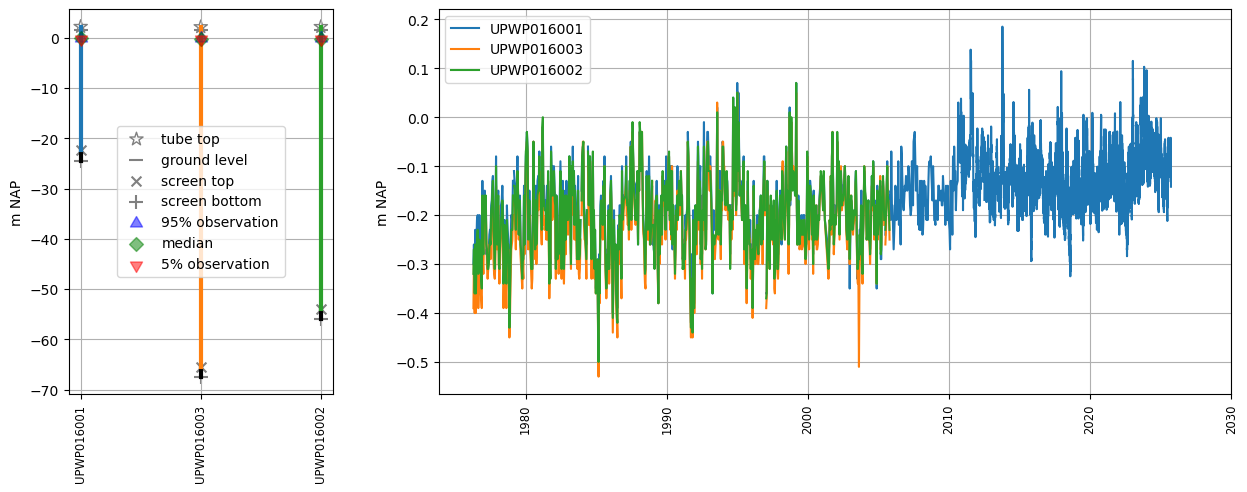

In [29]:
oc.plots.section_plot(plot_obs=True)

GroundwaterObs UPWP016001
-----metadata------
name : UPWP016001 
x : 137401.64297031244 
y : 458893.6835282785 
location : B31H0580 
filename :  
source : lizard 
unit : m NAP 
tube_nr : 1 
screen_top : -22.43 
screen_bottom : -24.43 
ground_level : 1.58 
tube_top : 2.198 
metadata_available : True 

-----time series------
                     value  flag comment origin
peil_datum_tijd                                
1976-04-15 12:00:00 -0.300     0           hand
1976-04-28 12:00:00 -0.260     0           hand
1976-05-18 12:00:00 -0.330     0           hand
1976-06-02 12:00:00 -0.230     0           hand
1976-06-17 12:00:00 -0.300     0           hand
...                    ...   ...     ...    ...
2025-09-25 00:00:00 -0.075     0          diver
2025-09-25 03:00:00 -0.075     0          diver
2025-09-25 06:00:00 -0.078     0          diver
2025-09-25 09:00:00 -0.073     0          diver
2025-09-25 09:50:01 -0.142     0           hand

[34351 rows x 4 columns]


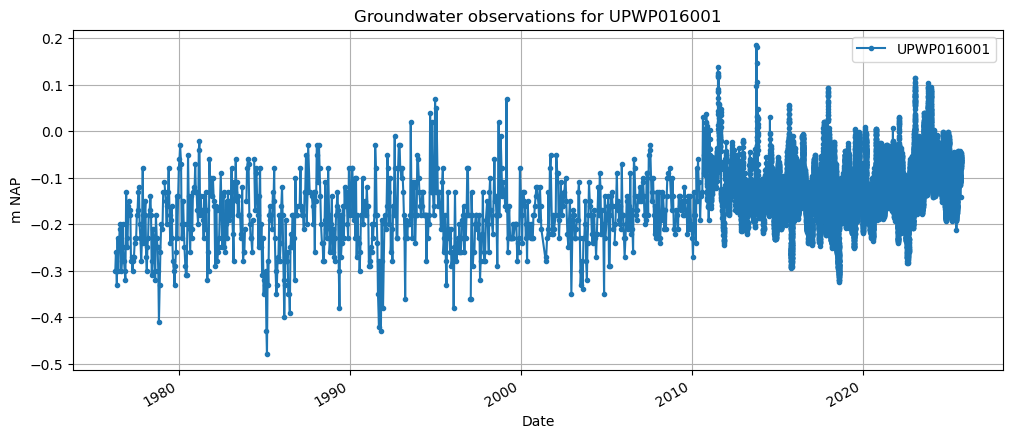

In [34]:
gw_lizard = hpd.GroundwaterObs.from_lizard(
    "UPWP016",
    tmin="1900-01-01",
    tmax="2030-01-01",
    organisation="vitens",
    auth=auth,
)
print(gw_lizard)

ax = gw_lizard["value"].plot(
    figsize=(12, 5),
    marker=".",
    grid=True,
    label=gw_lizard.name,
    legend=True,
    xlabel="Date",
    ylabel="m NAP",
    title="Groundwater observations for " + gw_lizard.name,
)

In [31]:
print(gw_lizard["flag"].value_counts(normalize=True) * 100)
gw_lizard[gw_lizard["flag"] == "onbetrouwbaar"]

flag
0    99.959244
1     0.017467
7     0.014556
6     0.005822
3     0.002911
Name: proportion, dtype: float64


,UPWP016001
x,137401.64297
y,458893.683528
location,B31H0580
filename,
source,lizard
unit,m NAP
tube_nr,1
screen_top,-22.43
screen_bottom,-24.43
ground_level,1.58


INFO:hydropandas.io.knmi.get_knmi_obs:get KNMI data from station nearest to coordinates (137401.64297031244, 458893.6835282785) and meteovariable RH
INFO:hydropandas.io.knmi.fill_missing_measurements:knmi station De Bilt has no measurements for RH after 2025-09-25 01:00:00 and an end date of 2025-09-25 09:50:01 was requested. Changing end to 2025-09-25 01:00:00
INFO:hydropandas.io.knmi._add_missing_indices:station 260 has no measurements after 2025-09-25 01:00:00
INFO:hydropandas.io.knmi.get_knmi_obs:get KNMI data from station nearest to coordinates (137401.64297031244, 458893.6835282785) and meteovariable EV24
INFO:hydropandas.io.knmi.fill_missing_measurements:knmi station De Bilt has no measurements for EV24 after 2025-09-25 01:00:00 and an end date of 2025-09-25 09:50:01 was requested. Changing end to 2025-09-25 01:00:00
INFO:hydropandas.io.knmi._add_missing_indices:station 260 has no measurements after 2025-09-25 01:00:00
INFO:pastas.timeseries._fill_nan:Time Series 'value': 9 nan-

[<Axes: xlabel='peil_datum_tijd', ylabel='Head'>,
 <Axes: >,
 <Axes: title={'right': "Stresses: ['RH', 'EV24']"}, ylabel='Rise'>,
 <Axes: title={'center': 'Step response'}>,
 <Axes: title={'left': 'Model parameters ($n_c$=5)'}>]

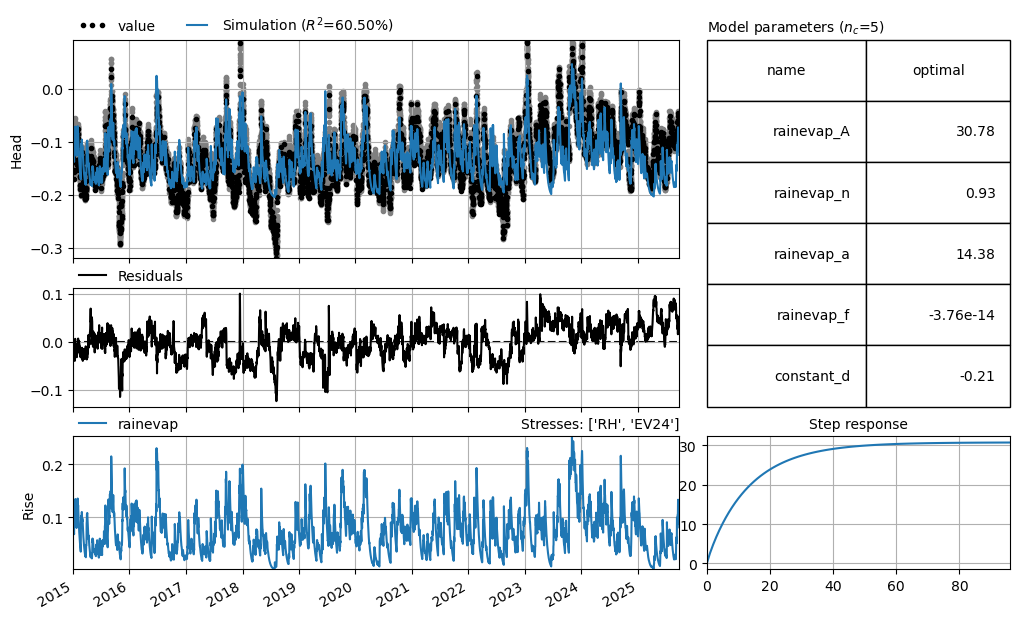

In [32]:
# Get the precipitation and evaporation data from the KNMI
precipitation = hpd.PrecipitationObs.from_knmi(
    xy=(gw_lizard.x, gw_lizard.y),
    start=gw_lizard.index[0],
    end=gw_lizard.index[-1],
    fill_missing_obs=True,
)
evaporation = hpd.EvaporationObs.from_knmi(
    xy=(gw_lizard.x, gw_lizard.y),
    meteo_var="EV24",
    start=gw_lizard.index[0],
    end=gw_lizard.index[-1],
    fill_missing_obs=True,
)

# Create a Pastas Model
ml = ps.Model(
    gw_lizard.loc[gw_lizard["origin"] == "diver", "value"], name=gw_lizard.name
)

# Add the recharge data as explanatory variable
ts1 = ps.RechargeModel(
    precipitation["RH"].resample("D").first(),
    evaporation["EV24"].resample("D").first(),
    ps.Gamma(),
    name="rainevap",
    settings=("prec", "evap"),
)

# Add the stressmodel to the model and solve for period after 2015
ml.add_stressmodel(ts1)
ml.solve(tmin="2015")
ml.plots.results(figsize=(10, 6))